# Pertemuan 9: Algoritma Klasifikasi (Bagian 1)
**Nama Lengkap:** Roland Albertian Sehapikang  
**NIM:** 240401010249  
**Kelas:** IF403  
**Mata Kuliah:** Data Science  
**Program Studi:** S1 - PJJ Informatika, Universitas Siber Asia

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split

X_raw, y_raw = make_classification(
    n_samples=1000,
    n_features=5,
    n_informative=3,
    n_redundant=1,
    random_state=42
)

X = pd.DataFrame(X_raw, columns=[f'Fitur_{i+1}' for i in range(5)])
y = pd.Series(y_raw, name='Target')

X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=0.2, random_state=42)

print("Ukuran Data Latih (Train):", X_tr.shape)
print("Ukuran Data Uji (Test)  :", X_te.shape)

Ukuran Data Latih (Train): (800, 5)
Ukuran Data Uji (Test)  : (200, 5)


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split

X_raw, y_raw = make_classification(
    n_samples=1000,
    n_features=5,
    n_informative=3,
    n_redundant=1,
    random_state=42
)

X = pd.DataFrame(X_raw, columns=[f'Fitur_{i+1}' for i in range(5)])
y = pd.Series(y_raw, name='Target')

X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=0.2, random_state=42)

print("Ukuran Data Latih (Train):", X_tr.shape)
print("Ukuran Data Uji (Test)  :", X_te.shape)

Ukuran Data Latih (Train): (800, 5)
Ukuran Data Uji (Test)  : (200, 5)


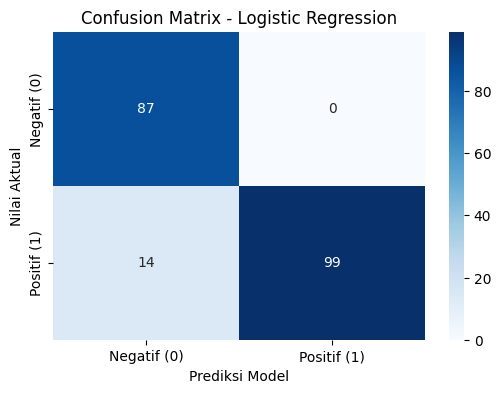

=== Evaluasi Model: Logistic Regression ===
Accuracy  : 0.9300
Precision : 1.0000
Recall    : 0.8761
F1-Score  : 0.9340

              precision    recall  f1-score   support

           0       0.86      1.00      0.93        87
           1       1.00      0.88      0.93       113

    accuracy                           0.93       200
   macro avg       0.93      0.94      0.93       200
weighted avg       0.94      0.93      0.93       200



In [3]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, precision_score, recall_score, f1_score

logreg = LogisticRegression(random_state=42)
logreg.fit(X_tr, y_tr)

y_pred_logreg = logreg.predict(X_te)

cm_logreg = confusion_matrix(y_te, y_pred_logreg)
plt.figure(figsize=(6, 4))
sns.heatmap(cm_logreg, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Negatif (0)', 'Positif (1)'],
            yticklabels=['Negatif (0)', 'Positif (1)'])
plt.xlabel('Prediksi Model')
plt.ylabel('Nilai Aktual')
plt.title('Confusion Matrix - Logistic Regression')
plt.show()

print("=== Evaluasi Model: Logistic Regression ===")
print(f"Accuracy  : {accuracy_score(y_te, y_pred_logreg):.4f}")
print(f"Precision : {precision_score(y_te, y_pred_logreg):.4f}")
print(f"Recall    : {recall_score(y_te, y_pred_logreg):.4f}")
print(f"F1-Score  : {f1_score(y_te, y_pred_logreg):.4f}\n")
print(classification_report(y_te, y_pred_logreg))

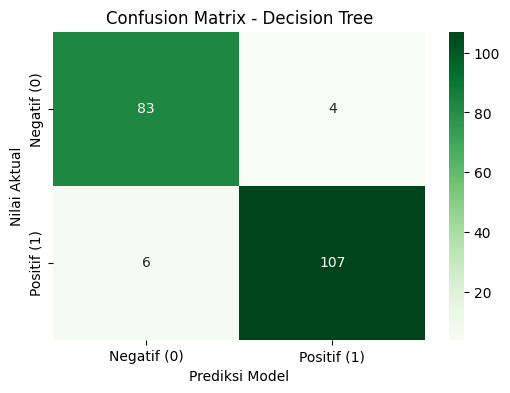

=== Evaluasi Model: Decision Tree Classifier ===
Accuracy  : 0.9500
Precision : 0.9640
Recall    : 0.9469
F1-Score  : 0.9554

              precision    recall  f1-score   support

           0       0.93      0.95      0.94        87
           1       0.96      0.95      0.96       113

    accuracy                           0.95       200
   macro avg       0.95      0.95      0.95       200
weighted avg       0.95      0.95      0.95       200



In [4]:
from sklearn.tree import DecisionTreeClassifier

dtree = DecisionTreeClassifier(random_state=42)
dtree.fit(X_tr, y_tr)

y_pred_dtree = dtree.predict(X_te)

cm_dtree = confusion_matrix(y_te, y_pred_dtree)
plt.figure(figsize=(6, 4))
sns.heatmap(cm_dtree, annot=True, fmt='d', cmap='Greens',
            xticklabels=['Negatif (0)', 'Positif (1)'],
            yticklabels=['Negatif (0)', 'Positif (1)'])
plt.xlabel('Prediksi Model')
plt.ylabel('Nilai Aktual')
plt.title('Confusion Matrix - Decision Tree')
plt.show()

print("=== Evaluasi Model: Decision Tree Classifier ===")
print(f"Accuracy  : {accuracy_score(y_te, y_pred_dtree):.4f}")
print(f"Precision : {precision_score(y_te, y_pred_dtree):.4f}")
print(f"Recall    : {recall_score(y_te, y_pred_dtree):.4f}")
print(f"F1-Score  : {f1_score(y_te, y_pred_dtree):.4f}\n")
print(classification_report(y_te, y_pred_dtree))

---
## Kesimpulan dan Analisis

### 1. Hal yang Dipelajari
- Memahami konsep dasar supervised learning untuk permasalahan klasifikasi biner menggunakan dua algoritma: **Logistic Regression** dan **Decision Tree Classifier**.
- Mengukur performa model menggunakan instrumen **Confusion Matrix** (True Positive, True Negative, False Positive, False Negative) serta empat metrik evaluasi utama: **Accuracy, Precision, Recall,** dan **F1-Score**.

### 2. Temuan Utama & Interpretasi Metrik (Main Findings)
- Pada dataset seimbang (*balanced dataset*), nilai **Accuracy** pada Logistic Regression dan Decision Tree dapat memberikan gambaran performa secara umum.
- Logistic Regression menghasilkan batas keputusan linier yang stabil, sedangkan Decision Tree mampu menangkap hubungan non-linier antar fitur.
- **Interpretasi Metrik:** Pada dataset dengan sebaran kelas seimbang, **F1-Score** menjadi metrik pembanding terbaik karena menggabungkan Precision dan Recall secara harmonis untuk menilai konsistensi prediksi model di kedua kelas.

### 3. Keterbatasan & Pertanyaan Lanjutan
- **Keterbatasan:** Model Decision Tree yang dilatih tanpa pembatasan kedalaman (*pruning/max_depth*) berisiko mengalami *overfitting* terhadap data latih.
- **Pertanyaan/Pengembangan:** Bagaimanakah pengaruh teknik pembatasan kedalaman pohon (*pruning*) atau penggabungan beberapa pohon (*Ensemble Method*) seperti Random Forest dalam meningkatkan performa klasifikasi?